In [1]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from PIL import Image
import os

In [26]:
imgName = '18.jpg'
maskName = imgName.split('.')[0]+'.png'
img = Image.open(os.path.join(r"C:\Users\hp\Desktop\4_rect_1\1024\gtFine", maskName))
src_img = Image.open(os.path.join(r"C:\Users\hp\Desktop\4_rect_1\1024\leftImg8bit", imgName))
img = np.array(img)
src_img = np.array(src_img)

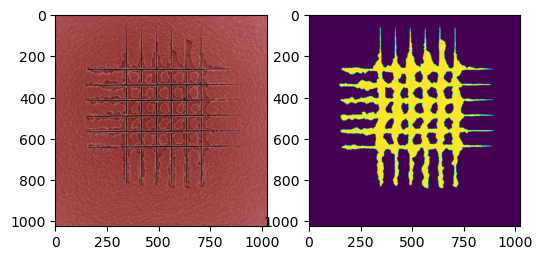

In [27]:
plt.figure(figsize=(6,12))
plt.subplot(1,2,1)
plt.imshow(src_img)
plt.subplot(1,2,2)
plt.imshow(img)

In [19]:
# [rowStart, rowEnd, colStart, colEnd]
fg_dict = {'1.jpg':[[295, 1299, 231, 1105]], '2.jpg':[[81,1283,317, 999]], '3.jpg':[[181,1275,99,1231]], 
           '4.jpg':[[]], '5.jpg':[[235,1107,293,1145]], '6.jpg':[[189, 1200, 203, 1085]], 
           '7.jpg':[[265, 1075, 189, 1015]], '8.jpg':[[275,1143,185,1063]], '9.jpg':[[215,1103, 303, 1169]], 
           '10.jpg':[[313,1205,165,1013]], '11.jpg':[[217,1281,95,1163]], '12.jpg':[[343,1037,323,995]], 
           '13.jpg':[[345,1213,155,1025]], '14.jpg':[[227,1127,187,1047]], '15.jpg':[[125,1200,105,1175]],
           '16.jpg':[[289,1137,200,1085]], '17.jpg':[[]]}
size = 1024
for key in fg_dict.keys():
    _plist = fg_dict[key]
    if _plist == [[]]:
        continue
    _new = [[0,0,0,0]]
    _new[0][0] = int( float(_plist[0][0])/1311.0 * size )
    _new[0][1] = int( float(_plist[0][1])/1311.0 * size )
    _new[0][2] = int( float(_plist[0][2])/1361.0 * size )
    _new[0][3] = int( float(_plist[0][3])/1361.0 * size )
    fg_dict[key] = _new
fg_dict_1024 = {'18.jpg':[[28,855, 137,925]],
           '19.jpg':[[190, 833, 189, 806]], '20.jpg':[[53,867,18,802]], '21.jpg':[[71,1023, 18,985]],
           '22.jpg':[[82, 821, 149,857]], '23.jpg':[[0,508,239, 939]], '24.jpg':[[131,853, 100,807]],
           '25.jpg':[[131,853, 100,807]], '26.jpg':[[186,902,204,895]], '27.jpg':[[231,918,103,781]]}
fg_dict.update(fg_dict_1024)

In [28]:
# 斜向上45°移动
rect = fg_dict[imgName][0]
img_mask = img.copy()
img_mask_roi = img_mask[rect[0]:rect[1], rect[2]:rect[3]].copy()
img_mask[rect[0]:rect[1], rect[2]:rect[3]] = 0

move_pixels = 1
left_r = 2
up_r = 0
img_mask[rect[0]-move_pixels*left_r:rect[1]-move_pixels*left_r, 
         rect[2]-move_pixels*up_r:rect[3]-move_pixels*up_r] = img_mask_roi

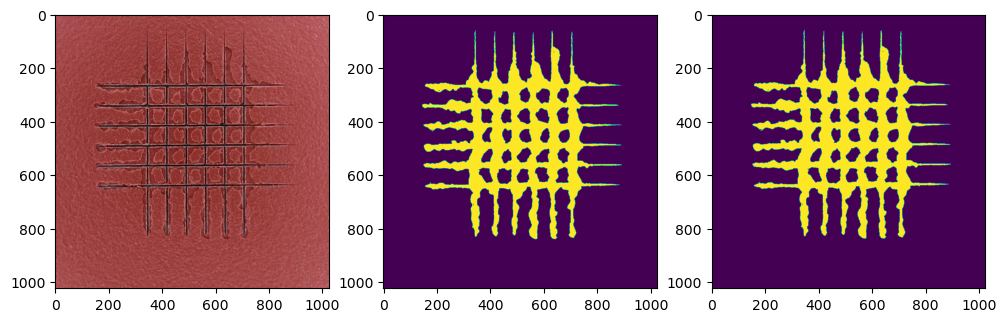

In [29]:
plt.figure(figsize=(12,36))
plt.subplot(1,3,1)
plt.imshow(src_img)
plt.subplot(1,3,2)
plt.imshow(img)
plt.subplot(1,3,3)
plt.imshow(img_mask)

In [30]:
pixels_area_sum = np.count_nonzero(img == 1) + np.count_nonzero(img_mask == 1)
pixels_area_and = np.count_nonzero(np.logical_and(img == 1, img_mask == 1))
IOu1 = float(pixels_area_and) / (float(pixels_area_sum)-float(pixels_area_and))
print(IOu1)

pixels_area_sum = np.count_nonzero(img == 0) + np.count_nonzero(img_mask == 0)
pixels_area_and = np.count_nonzero(np.logical_and(img == 0, img_mask == 0))
IOu2 = float(pixels_area_and) / (float(pixels_area_sum)-float(pixels_area_and))
print(IOu2)

print((IOu1+IOu2)/2.)

0.918986628567979
0.9814019665133769
0.9501942975406779
